<a href="https://colab.research.google.com/github/lahiruC22/data-science-projects/blob/main/chronic-kidney-disease-prediction/notebooks/exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
kidney_disease_data = pd.read_csv(r'/content/drive/MyDrive/data/kidney_disease.csv')
kidney_disease_data.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [ ]:
data_description = pd.read_csv(r'/content/drive/MyDrive/data/data_description.txt', sep='-')
data_description = data_description.reset_index()
data_description.columns = ['abbv','column_names']

In [ ]:
data_description

,abbv,column_names
0,id,id
1,age,age
2,bp,blood pressure
3,sg,specific gravity
4,al,albumin
5,su,sugar
6,rbc,red blood cells
7,pc,pus cell
8,pcc,pus cell clumps
9,ba,bacteria


In [ ]:
kidney_disease_data.columns = data_description['column_names'].values
kidney_disease_data.head()

,id,age,blood pressure,specific gravity,albumin,sugar,red blood cells,pus cell,pus cell clumps,bacteria,...,packed cell volume,white blood cell count,red blood cell count,hypertension,diabetes mellitus,coronary artery disease,appetite,pedal edema,anemia,class
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [ ]:
kidney_disease_data.dtypes

,0
id,int64
age,float64
blood pressure,float64
specific gravity,float64
albumin,float64
sugar,float64
red blood cells,object
pus cell,object
pus cell clumps,object
bacteria,object


In [ ]:
def convert_types(df,features):
  df[features] = pd.to_numeric(df[features],errors='coerce')

In [ ]:
features = ['packed cell volume','white blood cell count','red blood cell count']

for feature in features:
  convert_types(kidney_disease_data,feature)

kidney_disease_data.head()

,id,age,blood pressure,specific gravity,albumin,sugar,red blood cells,pus cell,pus cell clumps,bacteria,...,packed cell volume,white blood cell count,red blood cell count,hypertension,diabetes mellitus,coronary artery disease,appetite,pedal edema,anemia,class
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


In [ ]:
kidney_disease_data.dtypes

,0
id,int64
age,float64
blood pressure,float64
specific gravity,float64
albumin,float64
sugar,float64
red blood cells,object
pus cell,object
pus cell clumps,object
bacteria,object


In [ ]:
kidney_disease_data.drop('id',axis=1,inplace=True)
kidney_disease_data.head()

,age,blood pressure,specific gravity,albumin,sugar,red blood cells,pus cell,pus cell clumps,bacteria,blood glucose random,...,packed cell volume,white blood cell count,red blood cell count,hypertension,diabetes mellitus,coronary artery disease,appetite,pedal edema,anemia,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


In [ ]:
def var_types(df):
  categorical_var = [column for column in df.columns if df[column].dtypes == 'object']
  numerical_var = [column for column in df.columns if df[column].dtypes != 'object']
  return categorical_var, numerical_var

In [ ]:
categorical_var, numerical_var = var_types(kidney_disease_data)

In [ ]:
categorical_var

['red blood cells',
 'pus cell',
 'pus cell clumps',
 'bacteria',
 'hypertension',
 'diabetes mellitus',
 'coronary artery disease',
 'appetite',
 'pedal edema',
 'anemia',
 'class']

In [ ]:
numerical_var

['age',
 'blood pressure',
 'specific gravity',
 'albumin',
 'sugar',
 'blood glucose random',
 'blood urea',
 'serum creatinine',
 'sodium',
 'potassium',
 'haemoglobin',
 'packed cell volume',
 'white blood cell count',
 'red blood cell count']

In [ ]:
for column in categorical_var:
  print('{} has {} Unique Values'.format(column,kidney_disease_data[column].unique()))

red blood cells has [nan 'normal' 'abnormal'] Unique Values
pus cell has ['normal' 'abnormal' nan] Unique Values
pus cell clumps has ['notpresent' 'present' nan] Unique Values
bacteria has ['notpresent' 'present' nan] Unique Values
hypertension has ['yes' 'no' nan] Unique Values
diabetes mellitus has ['yes' 'no' '\tno' '\tyes' nan] Unique Values
coronary artery disease has ['no' 'yes' '\tno' nan] Unique Values
appetite has ['good' 'poor' nan] Unique Values
pedal edema has ['no' 'yes' nan] Unique Values
anemia has ['no' 'yes' nan] Unique Values
class has ['ckd' 'ckd\t' 'notckd'] Unique Values


In [ ]:
kidney_disease_data['diabetes mellitus'] = kidney_disease_data['diabetes mellitus'].replace(
    to_replace={' yes':'yes','\tno':'no','\tyes':'yes'})
kidney_disease_data['coronary artery disease'] = kidney_disease_data['coronary artery disease'].replace(
    to_replace={'\tno':'no'})
kidney_disease_data['class'] = kidney_disease_data['class'].replace(
    to_replace={'ckd\t':'ckd'})
for column in categorical_var:
  print('{} has {} Unique Values'.format(column,kidney_disease_data[column].unique()))

red blood cells has [nan 'normal' 'abnormal'] Unique Values
pus cell has ['normal' 'abnormal' nan] Unique Values
pus cell clumps has ['notpresent' 'present' nan] Unique Values
bacteria has ['notpresent' 'present' nan] Unique Values
hypertension has ['yes' 'no' nan] Unique Values
diabetes mellitus has ['yes' 'no' nan] Unique Values
coronary artery disease has ['no' 'yes' nan] Unique Values
appetite has ['good' 'poor' nan] Unique Values
pedal edema has ['no' 'yes' nan] Unique Values
anemia has ['no' 'yes' nan] Unique Values
class has ['ckd' 'notckd'] Unique Values


In [ ]:
total_numerical_var = len(numerical_var)
total_categorical_var = len(categorical_var)

print('Numerical Vars: {}, Categorical Vars: {}'.format(
    total_numerical_var,
    total_categorical_var))

Numerical Vars: 14, Categorical Vars: 11


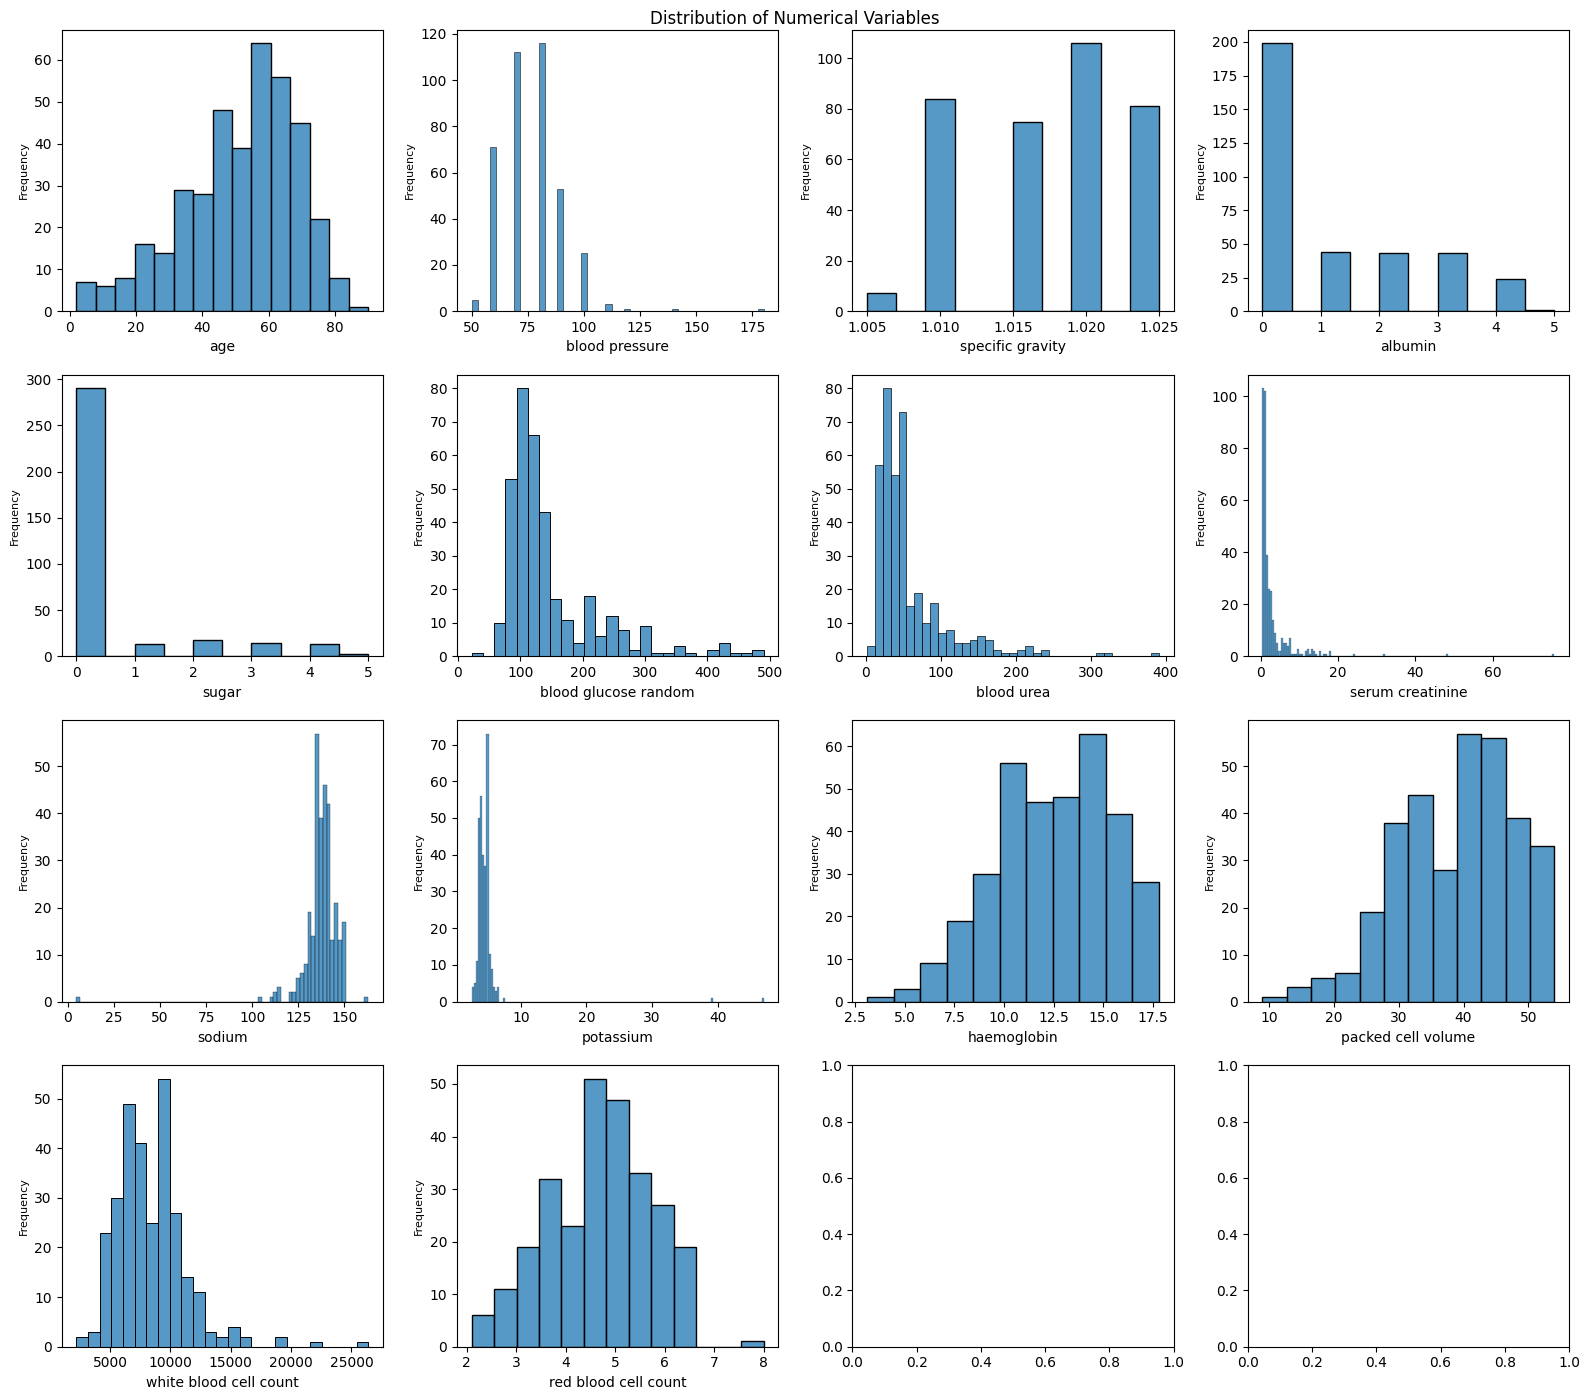

In [ ]:
figure, axes = plt.subplots(4,4,figsize=(16,15))
figure.suptitle('Distribution of Numerical Variables',y=0.93)
for i,ax in enumerate(numerical_var):
  sns.histplot(data=kidney_disease_data,x=ax,ax=axes[i//4,i%4])
  axes[i//4,i%4].set_xlabel(ax,fontsize=10)
  axes[i//4,i%4].set_ylabel('Frequency', fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.95])